In [1]:
from nilearn import plotting
from nilearn.plotting import cm
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torchio as tio
from pathlib import Path

/home/caleb/miniconda3/envs/image-processing/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#Defining where our data is stored
datadir = Path("/home/caleb/UCSF-PDGM-v5")

#building the arrays of mri's and tumor masks (sorted)
def build_dataset(datadir):

    image_paths = sorted(datadir.rglob("*T1_bias.nii.gz"))
    label_paths = sorted(datadir.rglob("*tumor_segmentation.nii.gz"))
    assert len(image_paths) == len(label_paths), "Number of images and labels do not match!"
    return image_paths, label_paths
    




In [3]:
#combine the mri's and masks into tio subjects
def build_subjects(image_paths, label_paths):

    subjects = []
    for (image_path, label_path) in zip(image_paths, label_paths):

        subject = tio.Subject(
        mri=tio.ScalarImage(image_path),
        seg=tio.LabelMap(label_path),
        )
        subjects.append(subject)

    return subjects

In [ ]:
from torch.utils.data import random_split
#take our paired subjects and create patches i.e. small chunks of the image and mask for training

def build_patches(subjects, patch_size=64,patch_overlap=4):
    
    len_sub = len(subjects)

    train_len = int(0.8 * len_sub)
    val_len = len_sub - train_len
    lengths = [train_len, val_len]

    train_set, val_set = random_split(subjects, lengths)
    
    #normalize our data between 0 and one

    transform = tio.RescaleIntensity(out_min_max=(0, 1))

    train_dataset = tio.SubjectsDataset(train_set,transform=transform)
    val_dataset = tio.SubjectsDataset(val_set,transform=transform)

    #define our sampler
    sampler = tio.LabelSampler(patch_size = patch_size,label_name='seg', label_probabilities={0:0.15, 1:0.85})
    
    train_queue = tio.Queue(
        subjects_dataset=train_dataset,
        max_length=300,        
        samples_per_volume=8,  
        sampler=sampler,
        num_workers=4,
        shuffle_subjects=True,
        shuffle_patches=True
    )

    val_queue = tio.Queue(
        subjects_dataset=val_dataset,
        max_length=300,
        samples_per_volume=8, # Take 8 patches per validation subject
        sampler=sampler,
        num_workers=4
    )
    
    return train_queue, val_queue

/home/calebwentworth/miniconda3/envs/Image-Processing/lib/python3.13/site-packages/numpy/ma/core.py:2896: UserWarning: Warning: converting a masked element to nan.
  _data = np.array(data, dtype=dtype, copy=copy,


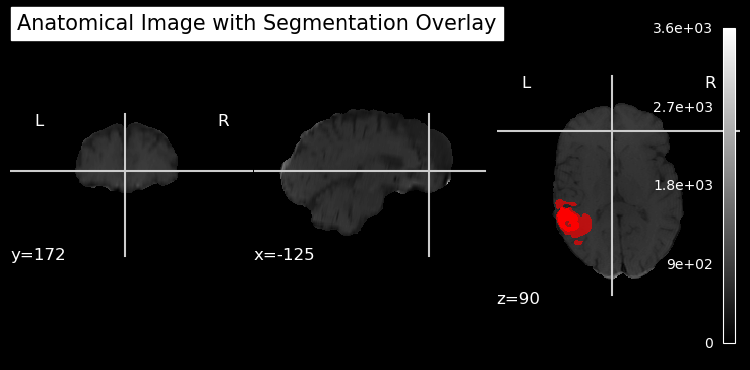

In [5]:
display = plotting.plot_anat(test_brain, title="Anatomical Image with Segmentation Overlay")
display.add_overlay(tumor,cmap=cm.red_transparent)

In [5]:
#define network
import snntorch as snn
from snntorch import utils, surrogate

class SpikingUnet(nn.Module):

    def __init__(self, in_channels ,out_chanels=2, beta=0.9):
        # layer parameters
        super().__init__()
        
        spike_grad = surrogate.fast_sigmoid()

        #encode l1

        self.enc1 = SNNConvBlock(in_channels, 16, beta, spike_grad)
        self.pool1 = nn.MaxPool3d(2)

        #encode l2
        self.enc2 = SNNConvBlock(16, 32, beta,spike_grad)
        self.pool2 = nn.MaxPool3d(2)

        #encode l3
        self.enc3 = SNNConvBlock(32, 64, beta, spike_grad)
        self.pool3 = nn.MaxPool3d(2)


        #bridge layer (bottom of the network)

        self.bridge = SNNConvBlock(64,128, beta, spike_grad)

        #decode l1
        self.up1 = nn.ConvTranspose3d(128, 64, kernel_size=2, stride=2)
        self.dec1 = SNNConvBlock(128, 64, beta, spike_grad)

        #decode l2
        self.up2 = nn.ConvTranspose3d(64, 32, kernel_size=2, stride=2)
        self.dec2 = SNNConvBlock(64, 32, beta, spike_grad)

        #decode l3
    
        self.up3 = nn.ConvTranspose3d(32, 16, kernel_size=2, stride=2)
        self.dec3 = SNNConvBlock(32,16, beta, spike_grad)

        #output layer
        self.output_conv = nn.Conv3d(16,out_chanels, kernel_size=1)
        self.output_leaky = snn.Leaky(beta=beta, spike_grad=spike_grad, init_hidden=True, output = True)
    
    def forward(self,x):
        #this is the feed forward
        #encoder
        e1 = self.enc1(x)
        p1 = self.pool1(e1)
        
        e2 = self.enc2(p1)
        p2 = self.pool2(e2)
        
        e3 = self.enc3(p2)
        p3 = self.pool3(e3)

        #bridge base layer
        b = self.bridge(p3)
        
        #decoder
        u1 = self.up1(b)
        cat1 = torch.cat([e3, u1], dim=1)
        d1 = self.dec1(cat1)
        
        u2 = self.up2(d1)
        cat2 = torch.cat([e2, u2], dim=1)
        d2 = self.dec2(cat2)
        
        u3 = self.up3(d2)
        cat3 = torch.cat([e1, u3], dim=1)
        d3 = self.dec3(cat3)
        
        spk, mem = self.output_leaky(self.output_conv(d3))
        return spk, mem
    
    def init_mem(self):
            utils.reset(self)


class SNNConvBlock(nn.Module):

    def __init__(self,in_channels,out_chanels, beta, spike_grad):
        
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv3d(in_channels, out_chanels, kernel_size=3, padding=1),
            nn.BatchNorm3d(out_chanels),
            snn.Leaky(beta=beta, spike_grad=spike_grad, init_hidden=True),

            nn.Conv3d(out_chanels, out_chanels,kernel_size=3,padding=1),
            nn.BatchNorm3d(out_chanels),
            snn.Leaky(beta=beta,spike_grad=spike_grad, init_hidden=True)
        )

    def forward(self, x):
        return self.block(x)
        


In [6]:
image_paths, label_paths = build_dataset(datadir=datadir)
subjects = build_subjects(image_paths,label_paths)


In [7]:
from tqdm import tqdm
from snntorch import spikegen

def train(model, loader, optimizer, loss_fn, device, spike_len=10,num_epochs=10):
    model.train()
    running_loss = 0


    loop = tqdm(loader, desc="Training", leave=True)

    for i, batch in enumerate(loop):
        data = batch['mri'][tio.DATA].to(device)
        targets = batch['seg'][tio.DATA].to(device).squeeze(1).long()
        targets[targets > 0] = 1
        spike_train = spikegen.rate(data,num_steps=spike_len)

        model.init_mem()
        mem_rec = []

        #submits spike rate to the ff network
        for step in range(spike_len):
            spike_out, mem_out = model(spike_train[step])
            mem_rec.append(mem_out)
        
        #calculate loss by taking the membrane potentials and the average value and applying the loss fn

        mem_rec = torch.stack(mem_rec)
        logits = mem_rec.mean(dim=0)
        loss = loss_fn(logits, targets)

        #back prop
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        loop.set_postfix(loss=loss.item(), avg_loss=running_loss / (i + 1))

    return running_loss / len(loader)



In [8]:
from monai.metrics import DiceMetric
from monai.utils import MetricReduction
from monai.transforms import AsDiscrete

def evaluate(model, loader, device, spike_len=10):
    model.eval()

    dice_metric = DiceMetric(include_background=False, reduction="mean", get_not_nans=False)
    post_pred = AsDiscrete(argmax=True, to_onehot=2)
    post_label = AsDiscrete(to_onehot=2)

    with torch.no_grad():
        for batch in tqdm(loader, desc="Eval"):
            data = batch['mri'][tio.DATA].to(device)
            targets = batch['seg'][tio.DATA].to(device).squeeze(1).long()
            targets[targets > 0] = 1
            spike_train = spikegen.rate(data, num_steps=spike_len)

            model.init_mem
            mem_rec = []

            for step in range(spike_len):
                _, mem_out = model(spike_train[step])
                mem_rec.append(mem_out)

            logits = torch.stack(mem_rec).mean(dim=0)
            
            val_outputs = [post_pred(i) for i in logits]

            val_label = [post_label(i.unsqueeze(0)) for i in targets]

            dice_metric(y_pred=val_outputs,y=val_label)

    mean_dice = dice_metric.aggregate().item()
    dice_metric.reset()

    print(f"\Dice score: {mean_dice:.4f}")
    
    return mean_dice

<>:37: SyntaxWarning: invalid escape sequence '\D'
<>:37: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_377355/3105871259.py:37: SyntaxWarning: invalid escape sequence '\D'
  print(f"\Dice score: {mean_dice:.4f}")


In [9]:
#main training area
from torch.utils.data import DataLoader


train_queue, val_queue = build_patches(subjects)

train_loader = DataLoader(train_queue, batch_size=1)
val_loader = DataLoader(val_queue,batch_size=1)
device = torch.device("cuda") if torch.cuda.is_available() else print("CUDA ERROR WAT????")
model = SpikingUnet(in_channels=1, out_chanels=2).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4, betas=(0.9, 0.999))
loss = nn.CrossEntropyLoss()

#snn spike train length
spike_len = 8


In [10]:
val_loader = DataLoader(val_queue, batch_size=1, num_workers=0)

batch = next(iter(val_loader))
shape = batch['mri'][tio.DATA].shape
if shape[-1 ==64]:
    print("good")
else:
    print("bad")

good


In [11]:
num_epochs = 40
spike_len = 8
best_dice = 0.0

train_loss_his = []

val_dice_his = []

for epoch in range(num_epochs):
    print(f"\n Epoch {epoch+1}/{num_epochs}")
    epoch_loss = train(model, train_loader, optimizer, loss, device, spike_len=spike_len)
    train_loss_his.append(epoch_loss)
    
    metrics = evaluate(model, val_loader, device, spike_len=spike_len)



 Epoch 1/40


Eval: 100%|██████████| 808/808 [00:42<00:00, 19.08it/s]


\Dice score: 0.0036

 Epoch 2/40


Eval: 100%|██████████| 808/808 [00:45<00:00, 17.69it/s] 


\Dice score: 0.0048

 Epoch 3/40


...

\Dice score: 0.2505

 Epoch 35/40


Eval: 100%|██████████| 808/808 [00:44<00:00, 18.33it/s]


\Dice score: 0.2150

 Epoch 36/40


Training:   0%|          | 0/3200 [00:04<?, ?it/s]


KeyboardInterrupt: 

In [12]:
metrics = evaluate(model, val_loader, device, spike_len=spike_len)

Eval: 100%|██████████| 808/808 [00:49<00:00, 16.36it/s] 

\Dice score: 0.1797


In [ ]:
def visualize_results(model, loader, device, spike_len=8, slice_index=32):
    model.eval()
    
    # 1. Get a single batch
    batch = next(iter(loader))
    data = batch['mri'][tio.DATA].to(device)
    target = batch['seg'][tio.DATA].to(device).squeeze(1) # Remove channel dim
    
    # 2. Run Inference
    spike_data = spikegen.rate(data, num_steps=spike_len)
    model.init_mem()
    
    mem_rec = []
    with torch.no_grad():
        for step in range(spike_len):
            _, mem_out = model(spike_data[step])
            mem_rec.append(mem_out)
    
    # 3. Process Output
    # Average over time -> (Batch, 2, D, H, W)
    final_logits = torch.stack(mem_rec).mean(dim=0)
    # Argmax to get class indices (0 or 1) -> (Batch, D, H, W)
    prediction = final_logits.argmax(dim=1)
    
    # 4. Plotting
    # We'll plot the first image in the batch
    img_idx = 0
    
    # Move to CPU for plotting
    mri_slice = data[img_idx, 0, :, :, slice_index].cpu().numpy()
    gt_slice = target[img_idx, :, :, slice_index].cpu().numpy()
    pred_slice = prediction[img_idx, :, :, slice_index].cpu().numpy()
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # MRI Image
    axes[0].imshow(mri_slice, cmap='gray')
    axes[0].set_title("MRI Input")
    axes[0].axis('off')
    
    # Ground Truth
    axes[1].imshow(gt_slice, cmap='gray')
    axes[1].set_title("Ground Truth Label")
    axes[1].axis('off')
     
    # Prediction
    axes[2].imshow(pred_slice, cmap='gray')
    axes[2].set_title("SNN Prediction")
    axes[2].axis('off')
    
    plt.show()

# --- Run the visualization ---
# slice_index=32 picks the middle slice of a 64x64x64 patch
visualize_results(model, val_loader, device, spike_len=spike_len, slice_index=32)

In [ ]:
#old code from early expirmients

slice_idx = int(155/2)
brain = batch[0]

brain_slice_2d = brain[:, slice_idx, :, :]


import matplotlib.pyplot as plt
import snntorch.spikeplot as splt
from IPython.display import HTML

fig, ax = plt.subplots()
# Pass the 2D slice series to the animator
anim = splt.animator(brain_slice_2d, fig, ax)
# plt.rcParams['animation.ffmpeg_path'] = 'C:\\path\\to\\your\\ffmpeg.exe'
plt.close(fig)

HTML(anim.to_html5_video())

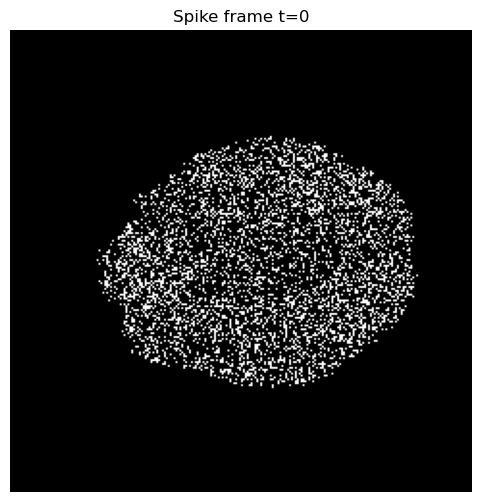

In [10]:
# plot a single time frame from the spike-generated 2D slice series
# choose time index to display
t_index = 0  # change this to any frame between 0 and brain_slice_2d.shape[0]-1

# extract image (handle torch tensor or numpy)
if isinstance(brain_slice_2d, torch.Tensor):
    img = brain_slice_2d[t_index].detach().cpu().numpy()
else:
    img = brain_slice_2d[t_index]

# ensure image is 2D
assert img.ndim == 2, "Selected frame must be 2D"

plt.figure(figsize=(6,6))
plt.imshow(img, cmap='gray', vmin=0, vmax=1)
plt.title(f"Spike frame t={t_index}")
plt.axis('off')
plt.show()